#### Return of Tesla Stock vs Return of SPY

In [43]:
import pandas as pd
import numpy as np

tesla = pd.read_csv("TSLA.csv")
spy = pd.read_csv("SPY.csv")
cvs = pd.read_csv("CVS.csv")

tesla = tesla.drop(0)
spy = spy.drop(0)
cvs = cvs.drop(0)

tesla = tesla[["Return", "Year"]]
spy = spy[["Return", "Year"]]
cvs = cvs[["Return", "Year"]]

all_tsla = tesla["Return"].to_numpy()
all_spy = spy["Return"].to_numpy()
all_cvs = cvs["Return"].to_numpy()
print("Polyfit for All Years:", np.polyfit(all_spy, all_tsla, 1))
print("Correlation Coefficient for All Years:", np.corrcoef(all_spy, all_tsla))

print("Std Dev for TSLA:", all_tsla.std())
print("Std Dev for SPY:", all_spy.std())

print("\n")

years = [2021.0, 2022.0, 2023.0, 2024.0, 2025.0]
for year in years:
    year_tsla = tesla[tesla["Year"]==year]["Return"].to_numpy()
    year_spy = spy[spy["Year"]==year]["Return"].to_numpy()
    print(f"Polyfit for {year}: {np.polyfit(year_spy, year_tsla, 1)}")
    print(f"Correlation Coefficient for {year}: {np.corrcoef(year_spy, year_tsla)}")

Polyfit for All Years: [ 2.02669766e+00 -9.40621481e-06]
Correlation Coefficient for All Years: [[1.         0.57086615]
 [0.57086615 1.        ]]
Std Dev for TSLA: 0.03824388115913444
Std Dev for SPY: 0.010772271462741604


Polyfit for 2021.0: [ 1.95450926e+00 -7.75648105e-05]
Correlation Coefficient for 2021.0: [[1.        0.4614405]
 [0.4614405 1.       ]]
Polyfit for 2022.0: [ 1.74024392 -0.0021051 ]
Correlation Coefficient for 2022.0: [[1.         0.63274337]
 [0.63274337 1.        ]]
Polyfit for 2023.0: [2.24759356e+00 1.22029400e-03]
Correlation Coefficient for 2023.0: [[1.         0.54371174]
 [0.54371174 1.        ]]
Polyfit for 2024.0: [2.37954989e+00 5.35086373e-04]
Correlation Coefficient for 2024.0: [[1.         0.47103222]
 [0.47103222 1.        ]]
Polyfit for 2025.0: [ 2.23581594e+00 -4.30000308e-04]
Correlation Coefficient for 2025.0: [[1.         0.68574886]
 [0.68574886 1.        ]]


In [45]:
tsla_std = all_tsla.std()
tsla_mean = all_tsla.mean()

tsla_pos = all_tsla > 0
tsla_neg = all_tsla < 0
tsla_outliers = (all_tsla < tsla_mean - 2*tsla_std) | (all_tsla > tsla_mean + 2*tsla_std)

print(f"TSLA Std Dev: {tsla_std}")
print(f"TSLA Positive Days: {tsla_pos.sum()}")
print(f"TSLA Negative Days: {tsla_neg.sum()}")
print(f"TSLA Outlier Days: {tsla_outliers.sum()}")
print(f"TSLA Outlier Days %: {round(tsla_outliers.sum()/len(all_tsla) * 100, 2)}")

cvs_std = all_cvs.std()
cvs_mean = all_cvs.mean()

cvs_pos = all_cvs > 0
cvs_neg = all_cvs < 0
cvs_outliers = (all_cvs < cvs_mean - 2*cvs_std) | (all_cvs > cvs_mean + 2*cvs_std)

print(f"\n\nCVS Std Dev: {cvs_std}")
print(f"CVS Positive Days: {cvs_pos.sum()}")
print(f"CVS Negative Days: {cvs_neg.sum()}")
print(f"CVS Outlier Days: {cvs_outliers.sum()}")
print(f"CVS Outlier Days %: {round(cvs_outliers.sum()/len(all_cvs) * 100, 2)}")

spy_std = all_spy.std()
spy_mean = all_spy.mean()

spy_pos = all_spy > 0
spy_neg = all_spy < 0
spy_outliers = (all_spy < spy_mean - 2*spy_std) | (all_spy > spy_mean + 2*spy_std)

print(f"\n\nSPY Std Dev: {spy_std}")
print(f"SPY Positive Days: {spy_pos.sum()}")
print(f"SPY Negative Days: {spy_neg.sum()}")
print(f"SPY Outlier Days: {spy_outliers.sum()}")
print(f"SPY Outlier Days %: {round(spy_outliers.sum()/len(all_spy) * 100, 2)}")

TSLA Std Dev: 0.03824388115913444
TSLA Positive Days: 647
TSLA Negative Days: 605
TSLA Outlier Days: 62
TSLA Outlier Days %: 4.94


CVS Std Dev: 0.017998806529438003
CVS Positive Days: 652
CVS Negative Days: 597
CVS Outlier Days: 49
CVS Outlier Days %: 3.91


SPY Std Dev: 0.010772271462741604
SPY Positive Days: 686
SPY Negative Days: 565
SPY Outlier Days: 59
SPY Outlier Days %: 4.7


##### Rank and Frequency of Project Hail Mary Text with Zipf-Mandelbrot Law

In [93]:
import string
import matplotlib.pyplot as plt
import numpy as np

text = """“What’s two plus two?”
Something about the question irritates me. I’m tired. I drift back to sleep.
A few minutes pass, then I hear it again.
“What’s two plus two?”
The soft, feminine voice lacks emotion and the pronunciation is identical
to the previous time she said it. It’s a computer. A computer is hassling me.
I’m even more irritated now.
“Lrmln,” I say. I’m surprised. I meant to say “Leave me alone”—a
completely reasonable response in my opinion—but I failed to speak.
“Incorrect,” says the computer. “What’s two plus two?”
Time for an experiment. I’ll try to say hello.
“Hlllch?” I say.
“Incorrect. What’s two plus two?”
What’s going on? I want to find out, but I don’t have much to work with. I
can’t see. I can’t hear anything other than the computer. I can’t even feel. No,
that’s not true. I feel something. I’m lying down. I’m on something soft. A
bed.
I think my eyes are closed. That’s not so bad. All I have to do is open
them. I try, but nothing happens.
Why can’t I open my eyes?
Open.
Aaaand…open!
Open, dang it!
Ooh! I felt a wiggle that time. My eyelids moved. I felt it.
Open!
My eyelids creep up and blinding light sears my retinas.
“Glunn!” I say. I keep my eyes open with sheer force of will. Everything is
white with shades of pain.
“Eye movement detected,” my tormenter says. “What’s two plus two?”
The whiteness lessens. My eyes are adjusting. I start to see shapes, but
nothing sensible yet. Let’s see…can I move my hands? No.
Feet? Also no.
But I can move my mouth, right? I’ve been saying stuff. Not stuff that
makes sense, but it’s something.
“Fffr.”
“Incorrect. What’s two plus two?”
The shapes start to make sense. I’m in a bed. It’s kind of…oval-shaped.
LED lights shine down on me. Cameras in the ceiling watch my every
move. Creepy though that is, I’m much more concerned about the robot arms.
The two brushed-steel armatures hang from the ceiling. Each has an
assortment of disturbingly penetration looking tools where hands should be.
Can’t say I like the look of that.
“Ffff…oooh…rrrr,” I say. Will that do?
“Incorrect. What’s two plus two?”
Dang it. I summon all my willpower and inner strength. Also, I’m starting
to panic a little. Good. I use that too.
“Fffoouurr,” I finally say.
“Correct.”
Thank God. I can talk. Sort of.
I breathe a sigh of relief. Wait—I just controlled my breathing. I take
another breath. On purpose. My mouth is sore. My throat is sore. But it’s my
soreness. I have control.
I’m wearing a breathing mask. It’s tight to my face and connected to a hose
that goes behind my head."""

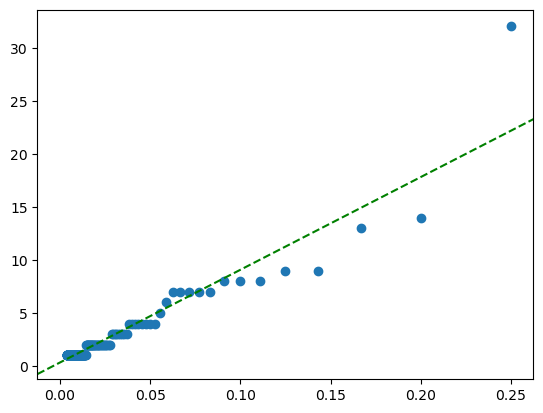

In [110]:
text = text.replace('“', '')
text = text.replace('”', '')
text = text.replace('…', '')
text = text.replace('-', ' ')
text = text.replace('.', '')
text = text.replace(',', '')


ls = text.split()
dict = {}
for word in ls:
    if (word in dict): dict[word] += 1
    else: dict[word] = 1

ranked_dict = sorted(dict.items(), key=lambda item: item[1], reverse=True)
frequencies = []
rank = []
a = 1
b = 3

for i in range(len(ranked_dict)):
    item = ranked_dict[i]
    rank.append((1/ ((i+1) + b)) ** a)
    frequencies.append(item[1])
    # print(f"\"{item[0]}\" Rank: {i+1}")
    # print(f"\"{item[0]}\" Frequency: {item[1]}\n")

plt.scatter(rank, frequencies)

m, b = np.polyfit(rank, frequencies, deg=1)
plt.axline(xy1=(0, b), slope=m, color='green', linestyle='--', label=f'Best Fit: y={m:.2f}x+{b:.2f}')